# European Dataset Experiment

## Import Libraries

In [16]:
# Import libraries

import json
import os
import time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mafese import Data

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression  # Just for evaluating during feature selection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, roc_curve

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

## Load Data and Scaling Data for Feature Selection

In [17]:
# Load Dataset
df = pd.read_csv('Credit_Card_Applications.csv')

In [18]:
df

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2644,15623369,0,44.33,0.000,2,8,4,2.500,1,0,0,0,2,0,1,1
2645,15732943,1,34.25,1.750,2,9,5,0.250,1,0,0,1,2,163,1,0
2646,15750545,0,45.00,4.585,2,4,8,1.000,0,0,0,1,1,240,1,0
2647,15809909,1,30.58,2.710,1,7,4,0.125,0,0,0,1,1,80,1,0


In [19]:
# Optional: Drop 'id' column if present
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

# Shuffle the data to mix Class 0 and Class 1
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare features and labels
X = df.drop('Class', axis=1)  # Features
y = df['Class']               # Labels

# Initialize mafese Data object
data = Data(X, y)

# Split the data
# (mafese automatically splits into training and testing sets)
data.split_train_test(test_size=0.3, random_state=42, inplace=True, stratify=y)  # You can adjust test_size and seed

# Scale the features
data.X_train, scaler_X = data.scale(data.X_train, scaling_methods=("standard", "minmax"))
data.X_test = scaler_X.transform(data.X_test)

# Encode the labels
data.y_train, scaler_y = data.encode_label(data.y_train)
data.y_test = scaler_y.transform(data.y_test)

# Print data shapes
print(f"Training Features Shape: {data.X_train.shape}")
print(f"Training Labels Shape: {data.y_train.shape}")
print(f"Testing Features Shape: {data.X_test.shape}")
print(f"Testing Labels Shape: {data.y_test.shape}")

Training Features Shape: (1854, 14)
Training Labels Shape: (1854,)
Testing Features Shape: (795, 14)
Testing Labels Shape: (795,)


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning:

X has feature names, but StandardScaler was fitted without feature names



In [20]:
data.y_test

array([0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,

## Exploratory Data Analysis

In [21]:
# load the dataset (read the CSV file)
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,1,22.25,0.46,2,4,4,0.125,0,0,0,1,2,280,56,0
1,1,19.42,6.50,2,9,8,1.460,1,1,7,0,2,80,2955,1
2,0,38.75,1.50,2,1,1,0.000,0,0,0,0,2,76,1,0
3,1,60.08,14.50,2,1,1,18.000,1,1,15,1,2,0,1001,1
4,0,22.42,11.25,1,14,8,0.750,1,1,4,0,2,0,322,1


In [22]:
# Show the dataset information, including data types and missing values
df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
count,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000,2649.000000
mean,0.675727,31.640393,4.788754,1.772744,7.395621,4.673462,2.249468,0.527746,0.429596,2.326161,0.461306,1.927520,183.892412,989.089090,0.449981
std,0.468191,12.049309,4.968918,0.428053,3.684980,1.989260,3.401925,0.499324,0.495112,4.571197,0.498595,0.294771,173.592382,5403.767653,0.497586
min,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.000000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.000000,28.580000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,160.000000,5.000000,0.000000
75%,1.000000,37.500000,7.500000,2.000000,10.000000,5.000000,2.710000,1.000000,1.000000,3.000000,1.000000,2.000000,272.000000,401.000000,1.000000
max,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.000000,1.000000,3.000000,2000.000000,100001.000000,1.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2649 entries, 0 to 2648
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      2649 non-null   int64  
 1   A2      2649 non-null   float64
 2   A3      2649 non-null   float64
 3   A4      2649 non-null   int64  
 4   A5      2649 non-null   int64  
 5   A6      2649 non-null   int64  
 6   A7      2649 non-null   float64
 7   A8      2649 non-null   int64  
 8   A9      2649 non-null   int64  
 9   A10     2649 non-null   int64  
 10  A11     2649 non-null   int64  
 11  A12     2649 non-null   int64  
 12  A13     2649 non-null   int64  
 13  A14     2649 non-null   int64  
 14  Class   2649 non-null   int64  
dtypes: float64(3), int64(12)
memory usage: 310.6 KB


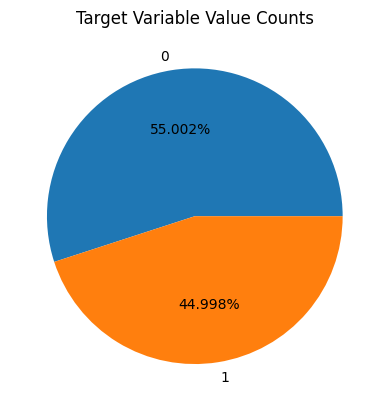

In [24]:
labels = df['Class'].unique()
sizes = df.Class.value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

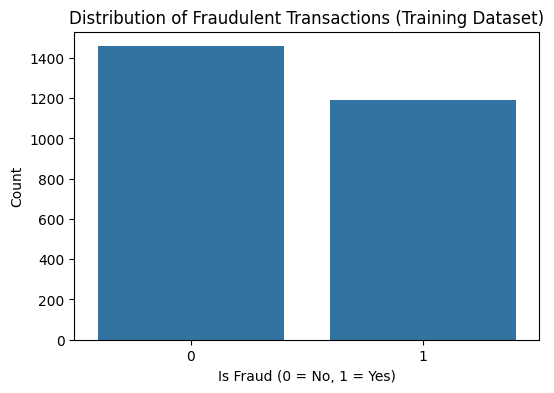

In [25]:
# Distribution of the target variable ('is_fraud') in the training dataset
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Fraudulent Transactions (Training Dataset)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

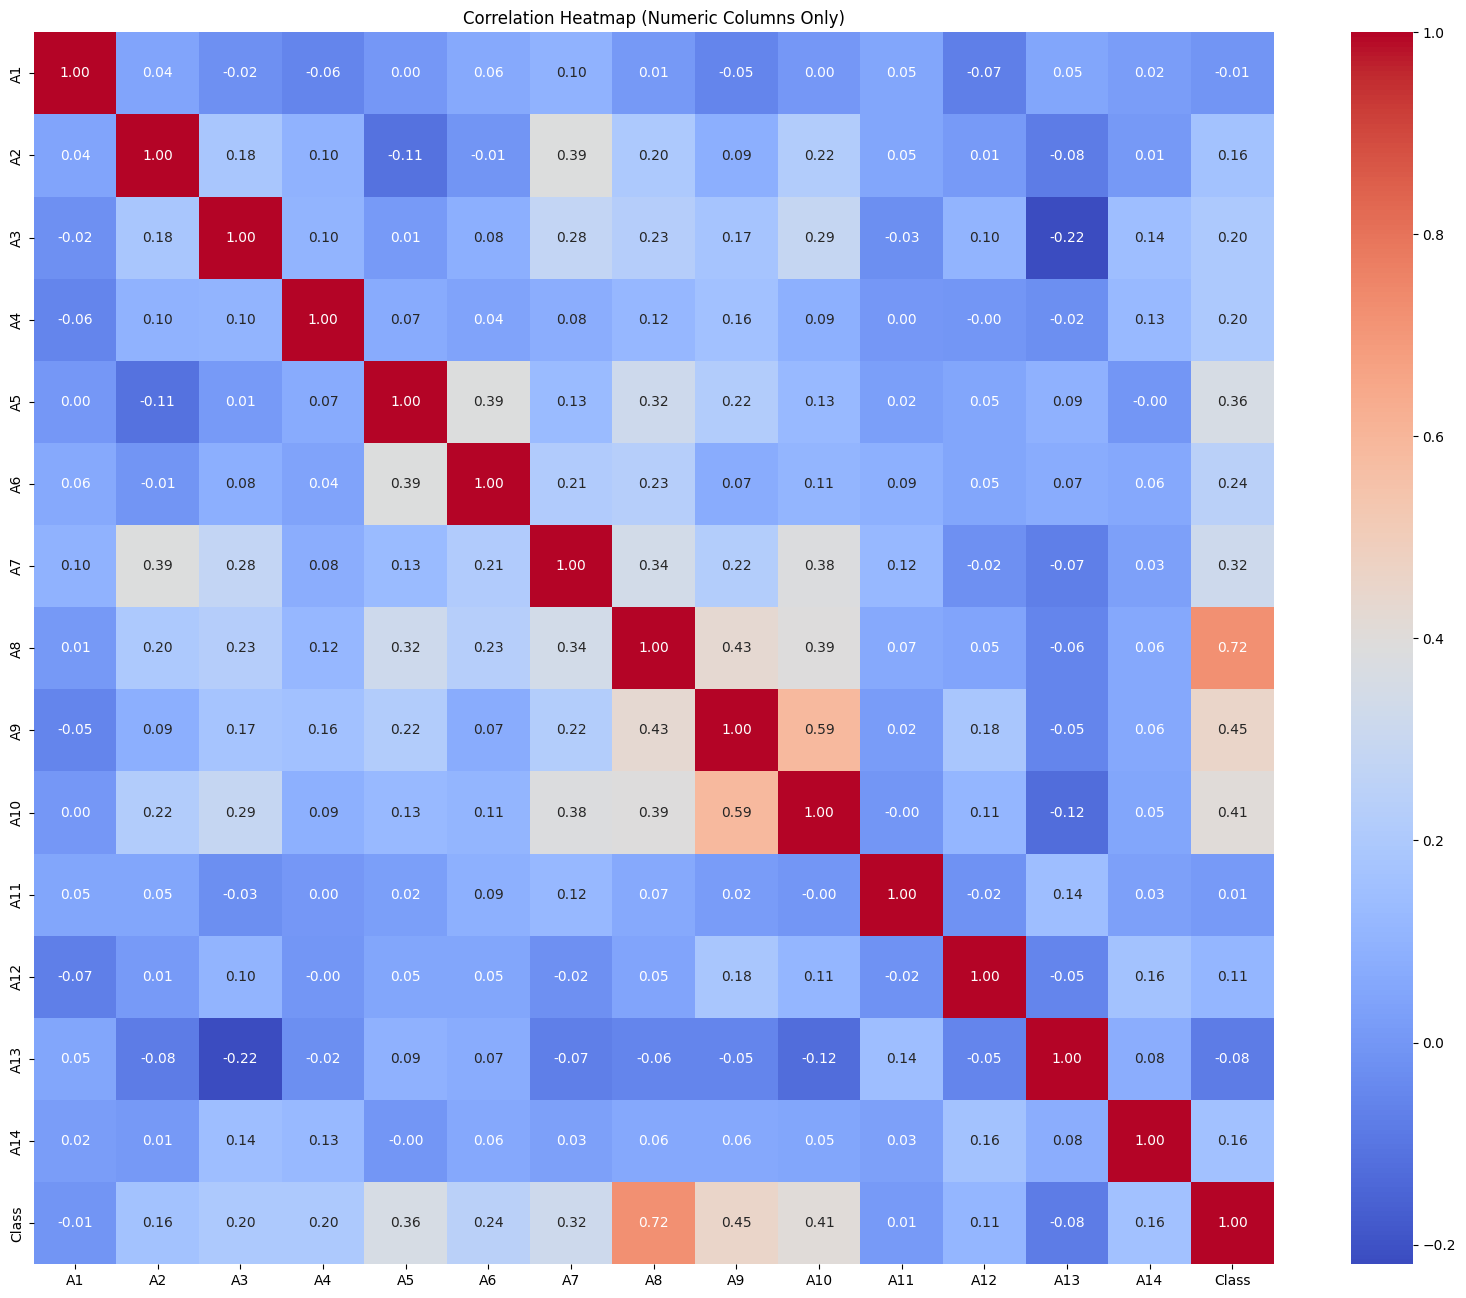

In [26]:
# Select only numeric columns for correlation analysis
numeric_data = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()

In [27]:
data.X_train

array([[1.        , 0.37097744, 0.02517857, ..., 0.5       , 0.1125    ,
        0.005     ],
       [1.        , 0.61774436, 0.55357143, ..., 0.5       , 0.076     ,
        0.0013    ],
       [0.        , 0.38090226, 0.14285714, ..., 0.5       , 0.24      ,
        0.        ],
       ...,
       [0.        , 0.13789474, 0.04464286, ..., 0.5       , 0.06      ,
        0.00809   ],
       [1.        , 0.14165414, 0.39732143, ..., 0.5       , 0.05      ,
        0.        ],
       [0.        , 0.2443609 , 0.18892857, ..., 0.5       , 0.0495    ,
        0.005     ]])

In [28]:
X

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,1,22.25,0.460,2,4,4,0.125,0,0,0,1,2,280,56
1,1,19.42,6.500,2,9,8,1.460,1,1,7,0,2,80,2955
2,0,38.75,1.500,2,1,1,0.000,0,0,0,0,2,76,1
3,1,60.08,14.500,2,1,1,18.000,1,1,15,1,2,0,1001
4,0,22.42,11.250,1,14,8,0.750,1,1,4,0,2,0,322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2644,0,26.17,2.000,2,5,3,0.000,0,0,0,1,2,276,2
2645,1,38.17,10.125,2,14,4,2.500,1,1,6,0,2,520,197
2646,1,67.75,5.500,2,10,9,13.000,1,1,1,1,2,0,1
2647,1,21.83,11.000,2,14,4,0.290,1,1,6,0,2,121,1


## Initializing The FPA Algorithm and Feature Selection Model

In [29]:
class FPAFeatureSelector:
    def __init__(self, model, n_flowers=20, max_iter=30, p=0.8):
        """
        Flower Pollination Algorithm for feature selection.

        Parameters:
        - model: a sklearn-compatible classifier
        - n_flowers: number of candidate solutions
        - max_iter: maximum number of iterations
        - p: switch probability between global and local pollination
        """
        
        self.model = model
        self.n_flowers = n_flowers
        self.max_iter = max_iter
        self.p = p
        self.best_solution = None
        self.best_score = -np.inf
        self.fitness_curve = []  # Store best fitness per iteration

    def _init_population(self, n_features):
        return np.random.randint(0, 2, (self.n_flowers, n_features))

    def _levy_flight(self, lambda_=1.5, size=1):
        sigma = (math.gamma(1 + lambda_) * np.sin(np.pi * lambda_ / 2) /
                 (math.gamma((1 + lambda_) / 2) * lambda_ * 2 ** ((lambda_ - 1) / 2))) ** (1 / lambda_)
        u = np.random.randn(size) * sigma
        v = np.random.randn(size)
        return u / (np.abs(v) ** (1 / lambda_))

    def _fitness(self, solution, X, y):
        if np.count_nonzero(solution) == 0:
            return 0
        X_selected = X[:, solution == 1]
        scores = cross_val_score(clone(self.model), X_selected, y, cv=5, scoring='accuracy')
        return np.mean(scores)

    def fit(self, X, y):
        n_features = X.shape[1]
        population = self._init_population(n_features)

        fitness = np.array([self._fitness(f, X, y) for f in population])
        best_index = np.argmax(fitness)
        self.best_solution = population[best_index].copy()
        self.best_score = fitness[best_index]

        self.fitness_curve.append(self.best_score)

        for t in range(self.max_iter):
            start_time = time.time()  # Start timing the epoch
            for i in range(self.n_flowers):
                flower = population[i].copy()

                if np.random.rand() < self.p:
                    L = self._levy_flight(size=n_features)
                    new_flower = flower + L * (self.best_solution - flower)
                else:
                    epsilon = np.random.rand()
                    j, k = np.random.choice(self.n_flowers, 2, replace=False)
                    new_flower = flower + epsilon * (population[j] - population[k])

                S = 1 / (1 + np.exp(-new_flower))
                new_flower_bin = np.where(np.random.rand(n_features) < S, 1, 0)

                new_fitness = self._fitness(new_flower_bin, X, y)

                if new_fitness > fitness[i]:
                    population[i] = new_flower_bin
                    fitness[i] = new_fitness

                    if new_fitness > self.best_score:
                        self.best_score = new_fitness
                        self.best_solution = new_flower_bin
                        
            # Calculate elapsed time
            elapsed_time = time.time() - start_time
    
            print(f"Iteration {t+1}/{self.max_iter}, Best Fitness: {self.best_score:.4f}, Time: {elapsed_time:.2f}s")

            self.fitness_curve.append(self.best_score)

        return self

    def transform(self, X):
        return X[:, self.best_solution == 1]

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def get_support(self):
        return self.best_solution.astype(bool)

    def get_selected_features(self, feature_names=None):
        if feature_names is None:
            return np.where(self.best_solution == 1)[0]
        else:
            return [name for i, name in enumerate(feature_names) if self.best_solution[i] == 1]

    def plot_fitness_curve(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.fitness_curve, marker='o', linestyle='-')
        plt.title('FPA Feature Selection: Best Fitness over Iterations')
        plt.xlabel('Iteration')
        plt.ylabel('Best Fitness (Accuracy)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Iteration 1/30, Best Fitness: 0.8673, Time: 0.28s
Iteration 2/30, Best Fitness: 0.8673, Time: 0.28s
Iteration 3/30, Best Fitness: 0.8679, Time: 0.33s
Iteration 4/30, Best Fitness: 0.8695, Time: 0.30s
Iteration 5/30, Best Fitness: 0.8695, Time: 0.31s
Iteration 6/30, Best Fitness: 0.8695, Time: 0.29s
Iteration 7/30, Best Fitness: 0.8695, Time: 0.31s
Iteration 8/30, Best Fitness: 0.8695, Time: 0.32s
Iteration 9/30, Best Fitness: 0.8695, Time: 0.30s
Iteration 10/30, Best Fitness: 0.8695, Time: 0.31s
Iteration 11/30, Best Fitness: 0.8695, Time: 0.28s
Iteration 12/30, Best Fitness: 0.8695, Time: 0.28s
Iteration 13/30, Best Fitness: 0.8695, Time: 0.30s
Iteration 14/30, Best Fitness: 0.8695, Time: 0.29s
Iteration 15/30, Best Fitness: 0.8695, Time: 0.29s
Iteration 16/30, Best Fitness: 0.8695, Time: 0.29s
Iteration 17/30, Best Fitness: 0.8695, Time: 0.29s
Iteration 18/30, Best Fitness: 0.8695, Time: 0.31s
Iteration 19/30, Best Fitness: 0.8706, Time: 0.30s
Iteration 20/30, Best Fitness: 0.8706, T

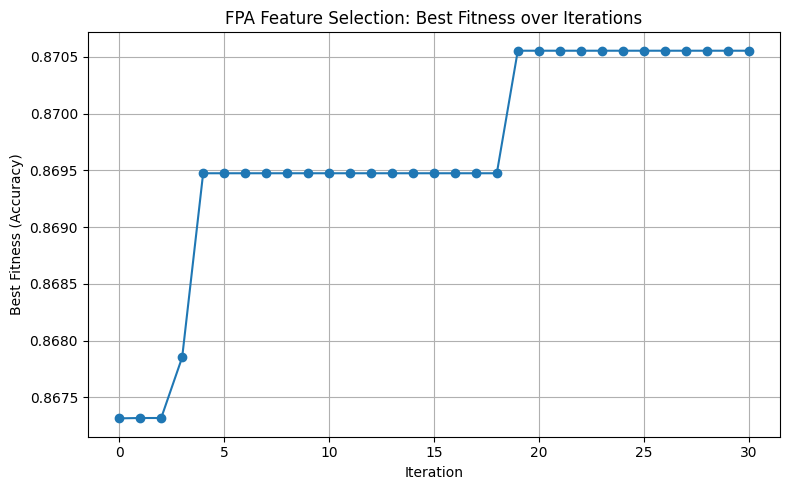

Original features: 14
Selected Features:[ 1  2  3  4  5  7  8  9 10 11 12 13]
Reduced Feature Set Shape:(1854, 12)


In [30]:
# Initialize model and FPA selector
model = LogisticRegression(random_state=42)
fpa_selector = FPAFeatureSelector(model=model, n_flowers=20, max_iter=30, p=0.8)

# Fit and transform your Training data
X_train_selected = fpa_selector.fit_transform(data.X_train, data.y_train)
selected_features = fpa_selector.get_selected_features()

# Reduce X_test as well
selected_indices = fpa_selector.get_selected_features()
X_test_selected = data.X_test[:, selected_indices]


# Plot fitness over iterations
fpa_selector.plot_fitness_curve()

# Get features selected and shape
print(f"Original features: {data.X_train.shape[1]}")
print(f"Selected Features:{selected_features}")
print(f"Reduced Feature Set Shape:{X_train_selected.shape}")

In [31]:
print(f"Original Dataset: {data.X_train.shape}")
print(f"Selected dataset: {X_test_selected.shape}")

Original Dataset: (1854, 14)
Selected dataset: (795, 12)


In [32]:
X_train_selected.shape[1]

12

In [33]:
X_test_selected

array([[0.26796992, 0.01339286, 0.5       , ..., 0.        , 0.464     ,
        0.        ],
       [0.21428571, 0.07142857, 0.5       , ..., 0.5       , 0.0905    ,
        0.        ],
       [0.12406015, 0.27982143, 0.        , ..., 0.5       , 0.092     ,
        0.        ],
       ...,
       [0.31578947, 0.53571429, 0.5       , ..., 0.5       , 0.        ,
        0.00134   ],
       [0.08646617, 0.34232143, 0.5       , ..., 0.5       , 0.04      ,
        0.0035    ],
       [0.26796992, 0.40178571, 0.5       , ..., 0.5       , 0.092     ,
        0.052     ]])

### Spiking Neural Network (SNN) Definition and Training ###

In [34]:
# --------- Simple SNN Model for Classification ------------- #

# -------- Surrogate Function --------
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input >= 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        # surrogate gradient: d(ReLU)/dx (approximate)
        surrogate_grad = torch.sigmoid(5 * input) * (1 - torch.sigmoid(5 * input))
        return grad_input * surrogate_grad

surrogate_spike_fn = SurrogateSpike.apply

# -------- Updated SNNLayer --------
class SNNLayer(nn.Module):
    def __init__(self, in_features, out_features, threshold=1.0, decay=0.9):
        super(SNNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.threshold = threshold
        self.decay = decay
        self.mem = None

    def forward(self, x):
        if self.mem is None:
            self.mem = torch.zeros(x.size(0), self.fc.out_features, device=x.device)

        current = self.fc(x)
        self.mem = self.mem * self.decay + current
        spike = surrogate_spike_fn(self.mem - self.threshold)
        self.mem = self.mem * (1 - spike)  # reset after spike
        return spike

    def reset(self):
        self.mem = None

# -------- Updated SNNClassifier --------
class SNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, threshold=1.0):
        super(SNNClassifier, self).__init__()
        self.snn1 = SNNLayer(input_dim, hidden_dim, threshold=threshold)
        self.snn2 = SNNLayer(hidden_dim, output_dim, threshold=threshold)

    def forward(self, x, time_steps=20):
        out_spikes = torch.zeros(x.size(0), self.snn2.fc.out_features, device=x.device)
        for t in range(time_steps):
            spike1 = self.snn1(x)
            spike2 = self.snn2(spike1)
            out_spikes += spike2
        return out_spikes  # output spike counts (higher means more confident)

    def reset(self):
        self.snn1.reset()
        self.snn2.reset()

# -------- Updated SNNTrainer --------
class SNNTrainer:
    def __init__(self, model, lr=1e-3, epochs=50, batch_size=32, device=None):
        self.model = model
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.losses = []

    def fit(self, X_train, y_train):
        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.long)

        dataset = torch.utils.data.TensorDataset(X_train, y_train)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(self.epochs):
            
            start_time = time.time()
            
            self.model.train()
            epoch_loss = 0
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                self.model.reset()
                out = self.model(xb)

                loss = criterion(out, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(loader)
            self.losses.append(avg_epoch_loss)

             # Calculate elapsed time
            elapsed_time = time.time() - start_time

            print(f"Epoch {epoch+1}/{self.epochs}, Loss: {avg_epoch_loss:.4f}, Time: {elapsed_time:.2f}s")

    def plot_training_loss(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.losses, label="Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.legend()
        plt.grid()
        plt.show()

    def evaluate(self, X_test, y_test):
        self.model.eval()
        X_test = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test = torch.tensor(y_test, dtype=torch.long).to(self.device)
    
        self.model.reset()
        out = self.model(X_test)  # raw logits or probabilities
        preds = torch.argmax(out, dim=1)
    
        y_true = y_test.cpu().numpy()
        y_pred = preds.cpu().numpy()
    
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")
    
        # MCC
        mcc = matthews_corrcoef(y_true, y_pred)
    
        # AUC-ROC Score (binary or one-vs-rest)
        if out.shape[1] == 2:
            probs = torch.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
            auc_roc = roc_auc_score(y_true, probs)
            
            # Plot ROC curve
            fpr, tpr, _ = roc_curve(y_true, probs)
            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC = {auc_roc:.4f}')
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            auc_roc = roc_auc_score(y_true, out.detach().cpu().numpy(), multi_class='ovr', average='weighted')
    
        # Print Metrics
        print("\nClassification Report:\n", classification_report(y_true, y_pred))
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)
        print("MCC:", mcc)
        print("AUC-ROC Score:", auc_roc)
    
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    
        return acc, precision, recall, f1, mcc, auc_roc

    def save_model(self, path="./snn_model.pth"):
        torch.save(self.model.state_dict(), path)

    def load_model(self, path="./snn_model.pth"):
        self.model.load_state_dict(torch.load(path, map_location=self.device))

Epoch 1/30, Loss: 0.4675, Time: 0.43s
Epoch 2/30, Loss: 0.3596, Time: 0.38s
Epoch 3/30, Loss: 0.3351, Time: 0.37s
Epoch 4/30, Loss: 0.3231, Time: 0.37s
Epoch 5/30, Loss: 0.3099, Time: 0.37s
Epoch 6/30, Loss: 0.3112, Time: 0.37s
Epoch 7/30, Loss: 0.2876, Time: 0.38s
Epoch 8/30, Loss: 0.2918, Time: 0.38s
Epoch 9/30, Loss: 0.2811, Time: 0.40s
Epoch 10/30, Loss: 0.2780, Time: 0.38s
Epoch 11/30, Loss: 0.2674, Time: 0.38s
Epoch 12/30, Loss: 0.2632, Time: 0.37s
Epoch 13/30, Loss: 0.2603, Time: 0.38s
Epoch 14/30, Loss: 0.2532, Time: 0.40s
Epoch 15/30, Loss: 0.2517, Time: 0.38s
Epoch 16/30, Loss: 0.2418, Time: 0.37s
Epoch 17/30, Loss: 0.2412, Time: 0.37s
Epoch 18/30, Loss: 0.2405, Time: 0.38s
Epoch 19/30, Loss: 0.2315, Time: 0.37s
Epoch 20/30, Loss: 0.2329, Time: 0.37s
Epoch 21/30, Loss: 0.2211, Time: 0.37s
Epoch 22/30, Loss: 0.2186, Time: 0.37s
Epoch 23/30, Loss: 0.2158, Time: 0.36s
Epoch 24/30, Loss: 0.2307, Time: 0.37s
Epoch 25/30, Loss: 0.2186, Time: 0.37s
Epoch 26/30, Loss: 0.2096, Time: 0

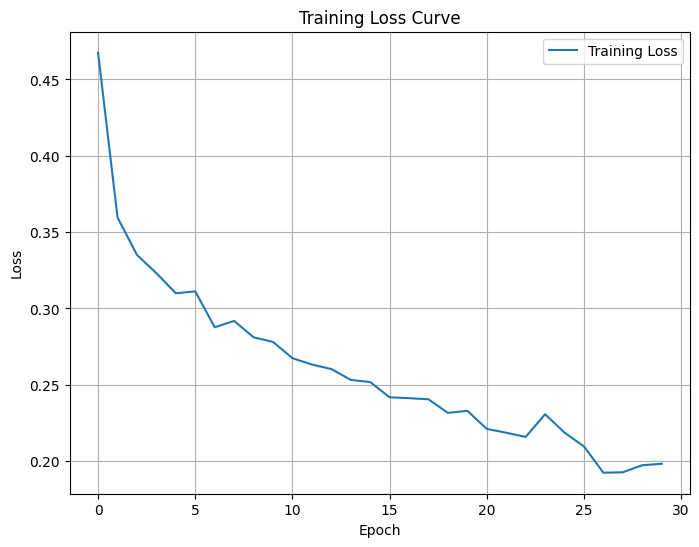

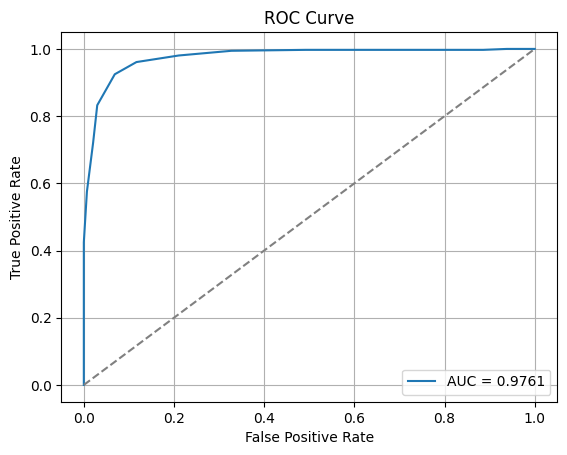


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       437
           1       0.96      0.83      0.89       358

    accuracy                           0.91       795
   macro avg       0.92      0.90      0.91       795
weighted avg       0.91      0.91      0.91       795

Accuracy: 0.9081761006289308
Precision: 0.9130337308879387
Recall: 0.9081761006289308
F1 Score: 0.9072935525243725
MCC: 0.8182908673975123
AUC-ROC Score: 0.9761291436022653


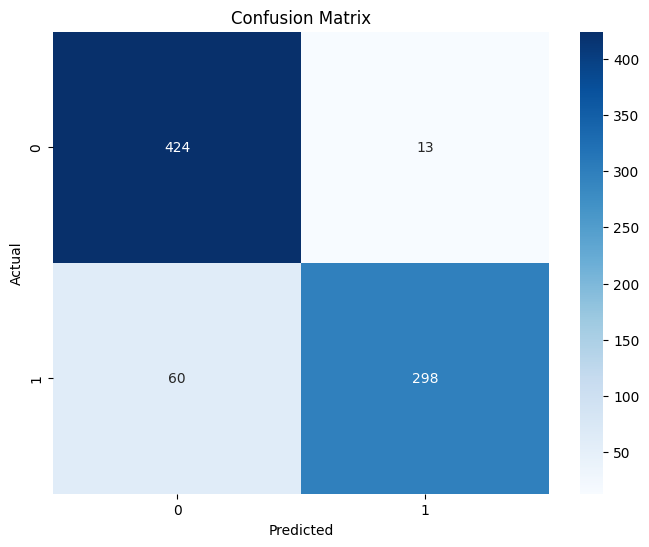

In [35]:
# Initialize
input_dim = X_train_selected.shape[1]
hidden_dim = 128
output_dim = len(np.unique(data.y_train))  # number of classes

snn_model = SNNClassifier(input_dim, hidden_dim, output_dim)

# Train
trainer = SNNTrainer(snn_model, lr=0.001, epochs=30, batch_size=32)
trainer.fit(X_train_selected, data.y_train)

# Plot Training Loss
trainer.plot_training_loss()

# Evaluate
trainer.evaluate(X_test_selected, data.y_test)

# Save Model
trainer.save_model("./bboa_selected_snn_model.pth")